# ARRAY ELEMENT RANKING - ENCODER-ONLY TRANSFORMERS



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from bertviz import head_view

from sklearn.model_selection import train_test_split
SEED = 207
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## 1. DATA ANALYSIS

In [2]:
df = pd.read_csv('ranking_dataset.csv')
# df.info()
# df.isna().sum()
df.describe()
# df.duplicated().sum()


,val_0,val_1,val_2,val_3,val_4,val_5,val_6,val_7,val_8,val_9,rank_0,rank_1,rank_2,rank_3,rank_4,rank_5,rank_6,rank_7,rank_8,rank_9
count,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,500.537200,506.623500,501.396300,501.42390,493.817300,495.837500,501.616300,505.314100,500.361700,500.02570,4.508600,4.546900,4.49630,4.511000,4.444500,4.443100,4.506400,4.544000,4.498000,4.501200
std,290.444477,289.410167,288.372805,289.29438,289.255414,290.777883,288.663129,288.731189,288.747163,290.38134,2.876031,2.888639,2.86056,2.866409,2.884086,2.878297,2.857022,2.867523,2.861261,2.882365
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,248.000000,255.750000,256.000000,251.00000,244.000000,240.000000,250.750000,257.000000,249.000000,248.00000,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,500.000000,511.000000,500.000000,505.00000,489.000000,496.000000,504.000000,504.000000,501.500000,501.00000,5.000000,5.000000,4.00000,5.000000,4.000000,4.000000,5.000000,5.000000,4.000000,4.000000
75%,755.000000,757.000000,752.250000,754.25000,745.000000,746.000000,753.250000,757.000000,752.000000,754.00000,7.000000,7.000000,7.00000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
max,999.000000,999.000000,999.000000,999.00000,999.000000,999.000000,999.000000,999.000000,999.000000,999.00000,9.000000,9.000000,9.00000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000


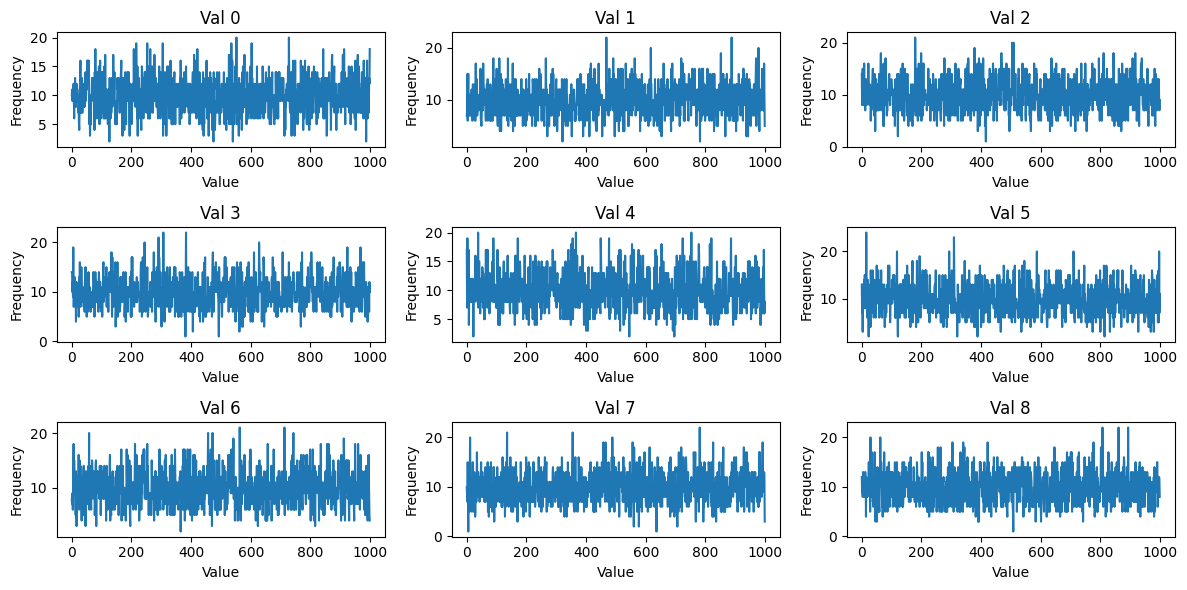

In [3]:
fig,ax = plt.subplots(3,3,figsize=(12,6))
ax = ax.flatten()
for i in range(9):
    ax[i].plot((df[f'val_{i}'].value_counts()).sort_index())
    ax[i].set_title(f'Val {i}')
    ax[i].set_xlabel('Value')
    ax[i].set_ylabel('Frequency')
fig.tight_layout()

- Both the plots and the values from the describe method (almost same mean and std of the values) show that the values are similarly distributed (the ballpark for caliming similarity or not is based on the disparity between the deltas and the actual range of values not any proper actual metric) 

## 2. Data Representation 

### 2.1 Test / Train / Validation splits

In [4]:
# If the sample size is large enough, the mean of independently sampled values will converge to its actual mean so theres no need of 
# stratification or other splitting methods.
# Columns names for sequence and ranks
seq_cols = [f'val_{i}' for i in range(10)]
rank_cols = [f'rank_{i}' for i in range(10)]

X = df[seq_cols]
y = df[rank_cols]
X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.2,random_state=SEED)
X_test, X_val, y_test, y_val = train_test_split(X_temp,y_temp,test_size=0.5,random_state=SEED)

print(f"Training samples mean and std per col : {X_train.mean()} , {X_train.std()}")
print(f"Validation samples mean and std per col : {X_val.mean()} , {X_val.std()}")
print(f"Testing samples mean and std per col : {X_test.mean()} , {X_test.std()}")

Training samples mean and std per col : val_0    501.642500
val_1    505.903750
val_2    499.409625
val_3    503.728000
val_4    492.448750
val_5    493.048250
val_6    501.359250
val_7    505.575000
val_8    502.136250
val_9    500.159125
dtype: float64 , val_0    290.311830
val_1    290.086323
val_2    287.363626
val_3    289.071779
val_4    289.129721
val_5    290.301900
val_6    288.388303
val_7    287.884634
val_8    289.189189
val_9    290.209627
dtype: float64
Validation samples mean and std per col : val_0    484.666
val_1    503.421
val_2    511.945
val_3    489.342
val_4    494.915
val_5    505.065
val_6    502.618
val_7    507.754
val_8    486.620
val_9    494.298
dtype: float64 , val_0    292.163673
val_1    289.560434
val_2    290.050877
val_3    291.967749
val_4    285.496715
val_5    294.172201
val_6    289.814376
val_7    288.633579
val_8    294.481930
val_9    292.201987
dtype: float64
Testing samples mean and std per col : val_0    507.566
val_1    515.584
val_2    50

### 2.2 Data Representation

In [5]:
d_model = 64
val_cnt = 1000          # values in [0, 999] - 1000 values
seq_len = 10            # each sequence is of length 10
n_heads = 4             

def normalise(x,method="minmax"):

    if method == "minmax":                                       # sequence wise normalisation
        min = x.min(dim=-1, keepdim=True).values                 # x is (B, 10), and keepdim to keep the 2nd dimension (B, 1)
        max = x.max(dim=-1, keepdim=True).values                          
        x = (x-min)/torch.max(max-min,torch.scalar_tensor(1e-6))
    elif method == "zscore":
        mean = x.mean(dim=-1, keepdim=True)
        std = x.std(dim=-1, keepdim=True)
        x = (x-mean)/torch.max(std,torch.scalar_tensor(1e-6))
    return x
class CategoricalEmbed(nn.Module):
    def __init__(self, d_model=d_model, val_cnt=val_cnt):
        super().__init__()
        self.emb = nn.Embedding(val_cnt,d_model)            # Embedding table : (val_cnt, d_model)
    def forward(self,x):                                    # x: (B, 10)
        return self.emb(x)                                  # (B, 10, d_model)

class NormProjectionEmbed(nn.Module):
    def __init__(self,d_model=d_model,norm="minmax"):
        super().__init__()
        self.norm = norm
        self.proj = nn.Linear(1, d_model)                   # Linear layer with common (W,b) for all values
    def forward(self,x):
        x = x.float()
        x = normalise(x,method=self.norm)
        return self.proj(x.unsqueeze(-1))                   # (B, 10) -> (B, 10, 1) -> (B, 10, d_model)

class PositionalEmbed(nn.Module):
    def __init__(self, d_model=d_model,normalise="zscore"):
        super().__init__()
        self.normalise = normalise
        self.d_model = d_model
        div = torch.exp(-np.log(10000.0) * (torch.arange(0, d_model, 2) / d_model))  # (d_model//2, )
        self.register_buffer("div",div)
    def forward(self, x):                                    # x: (B, 10)
        x = x.float()
        x = normalise(x,method=self.normalise)
        angles = x.unsqueeze(-1)*self.div.view(1, 1, -1)     # (B, 10, 1) * (1, 1, d_model//2) -> (B, 10, d_model//2)
        pe = torch.zeros(x.size(0), x.size(1), self.d_model, device=x.device)
        pe[:,:,0::2] = torch.sin(angles)
        pe[:,:,1::2] = torch.cos(angles)
        return pe                                            # (B, 10, d_model)

### 2.3 Dataset

In [6]:
class RankDataset(Dataset):
    def __init__(self,X,y):
        self.X = torch.tensor(X.values, dtype=torch.long)
        self.y = torch.tensor(y.values, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, index):
        return self.X[index], self.y[index]

BATCH = 128
train_loader = DataLoader(RankDataset(X_train,y_train), batch_size=BATCH,shuffle=True)
test_loader  = DataLoader(RankDataset(X_test, y_test), batch_size=BATCH, shuffle=False)
val_loader = DataLoader(RankDataset(X_val,y_val), batch_size=BATCH, shuffle=False)

## 3. Baselines

In [63]:
class MLPBaseline(nn.Module):
    def __init__(self,inp_dim=d_model,hidden_dim=[128,64],out_dim=seq_len,embedder=CategoricalEmbed()):
        super().__init__()
        self.embed = embedder()
        layers = []
        cur_dim = inp_dim
        for layer in hidden_dim:
            layers.append(nn.Linear(cur_dim,layer))
            layers.append(nn.ReLU())
            cur_dim = layer 
        layers.append(nn.Linear(cur_dim,out_dim))
        self.mlp  = nn.Sequential(*layers)
    
    def forward(self, x):
        emb = self.embed(x)
        return self.mlp(emb)
    
class GRUBaseline(nn.Module):
    def __init__(self, embedder, d_model=d_model, hidden=128, n_classes=seq_len):
        super().__init__()
        self.embed = embedder()
        self.gru = nn.GRU(d_model,hidden,3,batch_first=True, bidirectional=True)
        self.head = nn.Linear(2 * hidden, n_classes)
    def forward(self, x):
        out,_ = self.gru(self.embed(x))
        return self.head(out)


### 3.1 Training and Evaluation utils

- Token accuracy : Fraction of individual rank predictons correct across all positions
- Sequenece accuracy 

In [17]:
def train_epoch(model,loader,optimiser,criterion,device=device):
    model.train()
    tot_loss = 0
    for x,y in loader:
        x = x.to(device)
        y = y.to(device).view(-1)
        optimiser.zero_grad()
        logits = model(x).view(-1,seq_len)
        loss = criterion(logits,y)
        loss.backward()
        optimiser.step()
        tot_loss += loss.item()
    return tot_loss / len(loader)

def evaluate(model, loader, criterion=nn.CrossEntropyLoss(), device=device):
    model.eval()
    tot_loss, tok_correct, seq_correct, tot_tok, tot_seq = 0,0,0,0,0
    for x,y in loader:
        x = x.to(device)
        y = y.to(device)                                 # (B, 10)
        logits = model(x)                                # (B, 10, seq_len)
        loss = criterion(logits.view(-1,seq_len),y.view(-1))
        preds = logits.argmax(-1)                         # (B, 10)
        tok_correct += (preds == y).sum().item()
        seq_correct += (preds == y).all(-1).sum().item()
        tot_seq += y.size(0)
        tot_tok += y.numel()
        tot_loss += loss.item()
    return {'loss': tot_loss / len(loader), 'tok_acc':tok_correct/tot_tok, 'seq_acc':seq_correct/tot_seq}

def train(model, train_loader, val_loader,
          epochs = 30,
          lr = 3e-4,
          device = device,
          optim = torch.optim.Adam,
          crit = nn.CrossEntropyLoss,
          verbose=False,
          probe_seq=None,
          snapshot_every=5,
          name=None,
          **kwargs):
    model = model.to(device)
    optimizer = optim(model.parameters(), lr=lr, **kwargs)
    criterion = crit()
    history = []
    snapshots = []          # list of (epoch, [layer_weights]) 
    best_val = np.inf

    probe_x = None
    if probe_seq is not None:
        probe_x = torch.tensor([probe_seq], dtype=torch.long).to(device)

    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        val_res = evaluate(model, val_loader, criterion, device)
        history.append({'epoch':epoch+1, 'train_loss':train_loss, **val_res})

        if val_res['loss'] < best_val:
            best_val  = val_res['loss']
            if name:
                torch.save(model.state_dict(),f'best{name}.pt')
            else:
                torch.save(model.state_dict(),f'best{model.__class__.__name__}.pt')

        if probe_x is not None and (epoch)%snapshot_every == 0:
            model.eval()
            with torch.no_grad():
                _, all_weights = model.forward_with_weights(probe_x)
                snapshots.append((epoch +1, [w[0].cpu() for w in all_weights]))
            model.train()

        if (epoch)%5 == 0 and verbose:
            print(f"Epoch {epoch+1} | Train : {train_loss} | Val : {val_res['loss']} | Tok : {val_res['tok_acc']} | Seq : {val_res['seq_acc']}")

    return history, snapshots


In [65]:
print('MLP Baseline')
print('-' * 60)
mlp_model = MLPBaseline(inp_dim=d_model,embedder=CategoricalEmbed,out_dim=seq_len, hidden_dim=[64,32])
mlp_history, _ = train(mlp_model, train_loader, val_loader, epochs=50, lr=1e-3)
test_res = evaluate(mlp_model, test_loader, device=device)
print(f'Test tok accuracy: {test_res["tok_acc"]} | seq accuracy: {test_res["seq_acc"]}')

MLP Baseline
------------------------------------------------------------
Test tok accuracy: 0.3498 | seq accuracy: 0.0


In [66]:
print('GRU Baseline')
print('-' * 60)
gru_model = GRUBaseline(embedder=NormProjectionEmbed, d_model=d_model,n_classes=seq_len)
gru_history, _ = train(gru_model, train_loader, val_loader, epochs=50, lr=1e-3)
test_res = evaluate(gru_model, test_loader, device=device)
print(f'Test tok accuracy: {test_res["tok_acc"]} | seq accuracy: {test_res["seq_acc"]}')


GRU Baseline
------------------------------------------------------------
Test tok accuracy: 0.9291 | seq accuracy: 0.595


## 4. Encoder-only

In [ ]:
class RMSNorm(nn.Module):
    def __init__(self, d_model=d_model, eps=1e-6):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(d_model))             # learnable scaling parameter
        self.eps = eps
    def forward(self, x):
        rms = x.pow(2).mean(-1, keepdim=True).add(self.eps).sqrt() #(B, seq, 1)
        return self.scale* x/rms                                   #(B, seq, d_model)
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=d_model, n_heads=n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
    
    def forward(self, x):
        batch, seq_len, _ = x.shape
        H = self.n_heads
        dk = self.d_k
        Q = self.W_q(x).view(batch,seq_len,H,dk).transpose(1,2)
        K = self.W_k(x).view(batch,seq_len,H,dk).transpose(1,2)
        V = self.W_v(x).view(batch,seq_len,H,dk).transpose(1,2)

        attn_scores = (Q @ K.transpose(-2,-1)) / (dk**0.5)
        weights = torch.softmax(attn_scores,dim=-1)
        out = weights @ V
        out = out.transpose(1,2).contiguous().view(batch,seq_len,-1)
        return self.W_o(out), weights

class TransformerBlock(nn.Module):
    def __init__(self, d_model=d_model, n_heads=n_heads, hidden = 256,norm='layernorm'):
        super().__init__()
        self.attn = MultiHeadAttention(d_model,n_heads)
        self.ff = nn.Sequential(nn.Linear(d_model,hidden), nn.ReLU(), nn.Linear(hidden,d_model))
        Norm = RMSNorm if norm =='rms' else nn.LayerNorm
        self.ln1 = Norm(d_model)
        self.ln2 = Norm(d_model)
    
    def forward(self, x):
        attn_out, w = self.attn(x)
        x = self.ln1(x + attn_out)
        x = x + self.ff(self.ln2(x))
        return x, w

class EncoderOnlyTransformer(nn.Module):
    def __init__(self, embedder=NormProjectionEmbed(), d_model = d_model, n_heads=n_heads, n_classes = seq_len,
                 n_layers = 2,
                 hidden = 256,
                 use_pe = False,
                 norm='layernorm',
                 ):
        super().__init__()
        self.embed = embedder
        self.use_pe = use_pe
        self.blocks = nn.ModuleList([TransformerBlock(d_model,n_heads,hidden,norm) for _ in range(n_layers)])
        self.head = nn.Linear(d_model,n_classes)

        if use_pe:
            self.pe = nn.Embedding(seq_len,d_model)

    def _embed(self, x):
        x = self.embed(x)
        if self.use_pe:
            pos = torch.arange(x.shape[1], device=x.device).unsqueeze(0)
            x = x + self.pe(pos)
        return x

    def forward(self, x):
        x = self._embed(x)
        for block in self.blocks:
            x, _ = block(x)
        return self.head(x)

    def forward_with_weights(self, x):
        x = self._embed(x)
        all_weights = []
        for block in self.blocks:
            x, w = block(x)
            all_weights.append(w)
        return self.head(x), all_weights


## 5. Evaluation

### 5.1 Representation Ablations 


In [ ]:
PROBE_SEQ = [101,666,207,250,450,300,500,580,630,170]  

results = {}
criterion = nn.CrossEntropyLoss()
testing_configs = [
           ('NormProjectionEmbed_minmax',NormProjectionEmbed(norm="minmax")),
           ('NormProjectionEmbed_zscore',NormProjectionEmbed(norm="zscore")),
           ('CategoricalEmbed',CategoricalEmbed()),
           ('PositionalEmbed_none', PositionalEmbed(normalise=None)),
           ('PositionalEmbed_minmax', PositionalEmbed(normalise="minmax")),
           ('PositionalEmbed_zscore', PositionalEmbed(normalise="zscore")),
           ]
for name, embed in testing_configs:

    print(f" Embedder : {name}")
    model = EncoderOnlyTransformer(embedder=embed, n_layers=4)
    history, snapshots = train(model, train_loader, val_loader, epochs=30,probe_seq=PROBE_SEQ, snapshot_every=5)

    model.load_state_dict(torch.load('bestEncoderOnlyTransformer.pt', weights_only=True))
    test_res = evaluate(model, test_loader, criterion=criterion, device=device)
    results[name] = {'history': history, 'snapshots': snapshots, 'test': test_res, 'model': model}
    print(f'Test tok accuracy: {test_res["tok_acc"]} | seq accuracy: {test_res["seq_acc"]}')


 Embedder : NormProjectionEmbed_minmax
Test tok accuracy: 0.9938 | seq accuracy: 0.944
 Embedder : NormProjectionEmbed_zscore
Test tok accuracy: 0.9954 | seq accuracy: 0.956
 Embedder : CategoricalEmbed
Test tok accuracy: 0.8193 | seq accuracy: 0.2
 Embedder : PositionalEmbed_none
Test tok accuracy: 0.9886 | seq accuracy: 0.899
 Embedder : PositionalEmbed_minmax
Test tok accuracy: 0.9919 | seq accuracy: 0.932
 Embedder : PositionalEmbed_zscore
Test tok accuracy: 0.9945 | seq accuracy: 0.948


In [69]:
print('REPRESENTATION COMPARISON |')
print('-'*60)
for name, r in results.items():
    print(f'{name:40s} | tok_acc: {r["test"]["tok_acc"]:.4f} | seq_acc: {r["test"]["seq_acc"]:.4f}')

REPRESENTATION COMPARISON |
------------------------------------------------------------
NormProjectionEmbed_minmax               | tok_acc: 0.9938 | seq_acc: 0.9440
NormProjectionEmbed_zscore               | tok_acc: 0.9954 | seq_acc: 0.9560
CategoricalEmbed                         | tok_acc: 0.8193 | seq_acc: 0.2000
PositionalEmbed_none                     | tok_acc: 0.9886 | seq_acc: 0.8990
PositionalEmbed_minmax                   | tok_acc: 0.9919 | seq_acc: 0.9320
PositionalEmbed_zscore                   | tok_acc: 0.9945 | seq_acc: 0.9480


### 5.2 OOD Testing


In [75]:
# categorical embed wont work here because the embedding table was made to be (1000,64) 

test_model = results['NormProjectionEmbed_zscore']['model']
test_model.eval().to(device)

ood_sequences = {
    'ext_clusters' : [5, 12, 9, 3, 992, 985, 997, 980, 8, 994],
    'large_mag': np.random.permutation(np.linspace(1000,10000,10)),
    'all_ties': [5, 5, 5, 5, 5, 5, 5, 5, 5, 5],
    'outlier': [1,2,3,4,5,6,7,8,9,500]
}
ood_targets = {
    'ext_clusters' : np.argsort(ood_sequences['ext_clusters']).argsort(),
    'all_ties': np.zeros_like(ood_sequences['all_ties']),
    'large_mag': np.argsort(ood_sequences['large_mag']).argsort(),
    'outlier': np.argsort(ood_sequences['outlier']).argsort(),
}

print('Out Of Distribution Testing')
print('-'*60)
for name, seq in ood_sequences.items():
    x = torch.tensor([seq], dtype=torch.long).to(device)   # (1, 10)
    with torch.no_grad():
        logits = test_model(x)
    preds = logits.argmax(-1).squeeze().cpu().tolist()
    print(f'{name:20s} | input: {np.array(seq)}')
    print(f'{" ":20s} | pred:  {np.array(preds)}')
    print(f'{" ":20s} | target:{ood_targets[name]}')
    print()


Out Of Distribution Testing
------------------------------------------------------------
ext_clusters         | input: [  5  12   9   3 992 985 997 980   8 994]
                     | pred:  [1 3 2 0 7 5 9 5 2 8]
                     | target:[1 4 3 0 7 6 9 5 2 8]

large_mag            | input: [ 4000.  9000.  3000.  2000.  8000.  5000.  7000.  1000. 10000.  6000.]
                     | pred:  [3 8 2 1 7 4 6 0 9 5]
                     | target:[3 8 2 1 7 4 6 0 9 5]

all_ties             | input: [5 5 5 5 5 5 5 5 5 5]
                     | pred:  [8 8 8 8 8 8 8 8 8 8]
                     | target:[0 0 0 0 0 0 0 0 0 0]

outlier              | input: [  1   2   3   4   5   6   7   8   9 500]
                     | pred:  [2 2 2 2 3 3 0 7 7 9]
                     | target:[0 1 2 3 4 5 6 7 8 9]



### 5.3 Positional Encoding

In [71]:
use_pe = True
transformer = EncoderOnlyTransformer(NormProjectionEmbed(norm="zscore"), use_pe=use_pe).to(device)
history, _ = train(transformer, train_loader, val_loader, epochs=30)
transformer.load_state_dict(torch.load('bestEncoderOnlyTransformer.pt', weights_only=True))
res = evaluate(transformer, test_loader, criterion, device)
print(f'Test tok_acc: {res["tok_acc"]:.4f} | seq_acc: {res["seq_acc"]:.4f}')
print()
print('Out Of Distribution Testing')
print('-'*60)
for name, seq in ood_sequences.items():
    x = torch.tensor([seq], dtype=torch.long).to(device)
    with torch.no_grad():
        logits = transformer(x)
    preds = logits.argmax(-1).squeeze().cpu().tolist()
    print(f'{name:20s} | input: {np.array(seq)}')
    print(f'{" ":20s} | pred:  {np.array(preds)}')
    print(f'{" ":20s} | target:{ood_targets[name]}')
    print()


Test tok_acc: 0.9689 | seq_acc: 0.7690

Out Of Distribution Testing
------------------------------------------------------------
ext_clusters         | input: [  5  12   9   3 992 985 997 980   8 994]
                     | pred:  [2 2 2 1 7 6 7 6 2 8]
                     | target:[1 4 3 0 7 6 9 5 2 8]

large_mag            | input: [10000.  7000.  5000.  8000.  4000.  3000.  6000.  1000.  9000.  2000.]
                     | pred:  [9 6 4 7 3 2 5 0 8 1]
                     | target:[9 6 4 7 3 2 5 0 8 1]

all_ties             | input: [5 5 5 5 5 5 5 5 5 5]
                     | pred:  [0 0 0 0 0 0 0 0 0 0]
                     | target:[0 0 0 0 0 0 0 0 0 0]

outlier              | input: [  1   2   3   4   5   6   7   8   9 500]
                     | pred:  [0 9 9 8 8 8 8 8 8 9]
                     | target:[0 1 2 3 4 5 6 7 8 9]



## 5.4 Depth Ablation

In [72]:
depht_results = {}
layers = [1, 2, 4]
for i in layers:
    print(f" Layers : {i} ")
    model = EncoderOnlyTransformer(NormProjectionEmbed(norm="zscore"), n_layers=i)
    history, _ = train(model, train_loader, val_loader, epochs=30)
    model.load_state_dict(torch.load('bestEncoderOnlyTransformer.pt', weights_only=True))
    res = evaluate(model, test_loader, criterion, device)
    depht_results[i] = res
    print(f'Test tok_acc: {res["tok_acc"]:.4f} | seq_acc: {res["seq_acc"]:.4f}')


 Layers : 1 
Test tok_acc: 0.7236 | seq_acc: 0.0540
 Layers : 2 
Test tok_acc: 0.9844 | seq_acc: 0.8740
 Layers : 4 
Test tok_acc: 0.9952 | seq_acc: 0.9550


## 5.5 Different Normalisations

In [19]:
norm_results = {}
for norm in ['layernorm', 'rms']:
    model = EncoderOnlyTransformer(NormProjectionEmbed(norm="zscore"), n_layers=4, norm=norm)
    history, _ = train(model, train_loader, val_loader, epochs=30,name=norm)
    model.load_state_dict(torch.load(f"best{norm}.pt", weights_only=True))
    res = evaluate(model, test_loader, criterion=nn.CrossEntropyLoss(), device=device)
    norm_results[norm] = res
    print(f'{norm:12s} | tok_acc: {res["tok_acc"]:.4f} | seq_acc: {res["seq_acc"]:.4f}')

layernorm    | tok_acc: 0.9951 | seq_acc: 0.9530
rms          | tok_acc: 0.9947 | seq_acc: 0.9500


## Attention Scores Visualisation

Input:   [398, 286, 513, 293, 296, 550, 299, 215, 569, 913]
Preds:   [5 1 6 2 3 7 4 0 8 9]
Target:  [5 1 6 2 3 7 4 0 8 9]


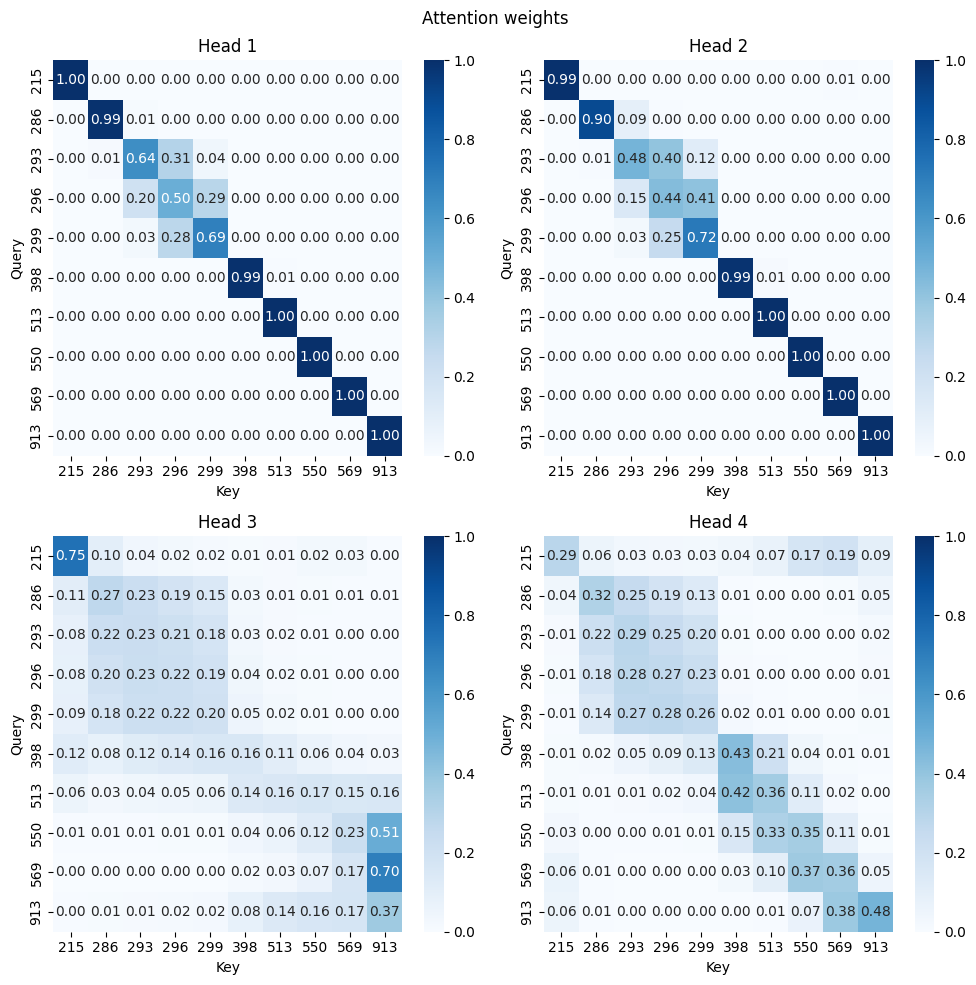

<IPython.core.display.Javascript object>

In [ ]:
def visualize_attention(transformer, seq, layer=-1):
    transformer.eval()
    with torch.no_grad():
        logits, all_weights = transformer.forward_with_weights(torch.tensor([seq], dtype=torch.long).to(device))

    preds = logits.argmax(-1).squeeze().cpu().tolist()
    print(f"Input:   {seq}\nPreds:   {np.array(preds)}\nTarget:  {np.argsort(seq).argsort()}")

    sort_idx = np.argsort(seq)
    tick_labels = [str(seq[i]) for i in sort_idx]
    w_sorted = all_weights[layer][0].cpu().numpy()[:,sort_idx,:][:,:,sort_idx]

    fig, axes = plt.subplots(n_heads//2, 2, figsize=(10, 10))
    for h, ax in enumerate(axes.flatten()):
        sns.heatmap(w_sorted[h], ax=ax, xticklabels=tick_labels, yticklabels=tick_labels,cmap='Blues', vmin=0, vmax=1, annot=True, fmt='.2f')
        ax.set(title=f'Head {h+1}', xlabel='Key', ylabel='Query')
    plt.suptitle('Attention weights')
    plt.tight_layout()
    plt.show()
    head_view(attention=all_weights, tokens=[str(v) for v in seq])


def plot_attention_evolution(snapshots, layer=3, seq=PROBE_SEQ):
    sort_idx = np.argsort(seq)
    tick_labels = [str(seq[i]) for i in sort_idx]
    fig, axes = plt.subplots(1, n_heads, figsize=(4*n_heads, 4))
    epoch0, lw0 = snapshots[0]
    imgs = []
    for h, ax in enumerate(axes.flatten()):
        w = lw0[layer][h].numpy()[sort_idx, :][:, sort_idx]
        im = ax.imshow(w, cmap='Blues', vmin=0, vmax=1)
        ax.set(title=f'Head {h+1}', xlabel='Key', ylabel='Query',xticks=range(len(seq)), yticks=range(len(seq)))
        ax.set_xticklabels(tick_labels)
        ax.set_yticklabels(tick_labels)
        imgs.append(im)
    plt.tight_layout()

    def update(frame):
        epoch, lw = snapshots[frame]
        for h in range(n_heads):
            imgs[h].set_data(lw[layer][h].numpy()[sort_idx, :][:, sort_idx])
        return imgs

    anim = FuncAnimation(fig, update, frames=len(snapshots), interval=600, blit=True)
    plt.close(fig)
    return HTML(anim.to_jshtml())


sample_seq = X_test.iloc[np.random.randint(1, 1000)].values.tolist()
best_model = results['NormProjectionEmbed_zscore']['model']
visualize_attention(best_model, sample_seq)
plot_attention_evolution(results['NormProjectionEmbed_zscore']['snapshots'], layer=2)

## Loss Plots

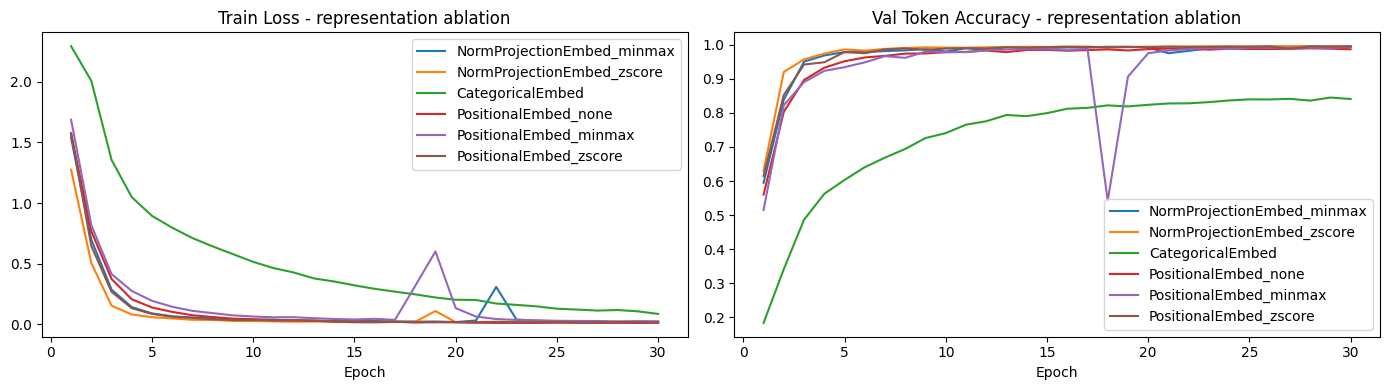

In [74]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for name, r in results.items():
    epochs = [h['epoch'] for h in r['history']]
    ax[0].plot(epochs, [h['train_loss'] for h in r['history']], label=name)
    ax[1].plot(epochs, [h['tok_acc']    for h in r['history']], label=name)

ax[0].set_title('Train Loss - representation ablation')
ax[0].set_xlabel('Epoch')
ax[0].legend()
ax[1].set_title('Val Token Accuracy - representation ablation')
ax[1].set_xlabel('Epoch')
ax[1].legend()
plt.tight_layout()
plt.show()